In [5]:
import numpy as np
import random

In [14]:
a = np.arange(1,11)
random.shuffle(a)
a

array([ 7,  5,  8,  3,  4,  6,  1,  9, 10,  2])

In [17]:
np.where(a % 2 == 0, a, 0)

array([ 0,  0,  8,  0,  4,  6,  0,  0, 10,  2])

In [26]:
a.reshape(2,5).ravel()
a = a * 3
a + a

array([126,  90, 144,  54,  72, 108,  18, 162, 180,  36])

In [64]:
import pandas as pd
import matplotlib as plt

In [30]:
pd.Series(a)

0    63
1    45
2    72
3    27
4    36
5    54
6     9
7    81
8    90
9    18
dtype: int64

In [31]:
pd.DataFrame(a.reshape(5,2))

,0,1
0,63,45
1,72,27
2,36,54
3,9,81
4,90,18


In [36]:
df = pd.read_csv('train_titanic.csv', index_col='PassengerId')

In [40]:
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [74]:
a = df['Fare'].quantile(0.95)

In [73]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [83]:
df[df.Fare > 10]
df[[True, False, True] * 297]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S


In [ ]:
df.iloc[:10, 3:6]

,Sex,Age,SibSp
PassengerId,,,
1,male,22.0,1
2,female,38.0,1
3,female,26.0,0
4,female,35.0,1
5,male,35.0,0
6,male,NaN,0
7,male,54.0,0
8,male,2.0,3
9,female,27.0,0


In [99]:
df[df.Fare > 30].loc[:10, 'Survived' : 'Sex']

,Survived,Pclass,Name,Sex
PassengerId,,,,
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female
7,0,1,"McCarthy, Mr. Timothy J",male
10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female


In [114]:
def processing(s):
    return s[:s.find('.')].split()[-1]
df['Title'] = df.Name.apply(processing)

In [126]:
df.groupby('Title').agg({"Fare" : ["mean", "median"]}).loc["Mr", ("Fare", "mean")]

24.44155996131528

KeyError: 'Mr.'

In [137]:
df.groupby('Title').agg({"Fare" : ["mean", "median"]})
df.Title.value_counts() > 10
b = ["Mr", "Miss", "Mrs", "Master"]
title_df = df[df.Title.isin(b)]
title_df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
PassengerId,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q,Mrs
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Miss


In [141]:
title_df.groupby(["Title", "Pclass"]).agg({"Fare" : "median"})

Fare
Title  Pclass           
Master 1       120.00000
       2        26.00000
       3        28.51250
Miss   1        91.75000
       2        13.00000
       3         8.75625
Mr     1        42.40000
       2        13.00000
       3         7.89580
Mrs    1        79.42500
       2        26.00000
       3        15.97500

In [145]:
pd.pivot_table(title_df, columns="Title", index="Pclass", values="Fare", aggfunc="median").style.background_gradient(cmap="twilight_shifted_r")

Title,Master,Miss,Mr,Mrs
Pclass,,,,
1,120.000000,91.750000,42.400000,79.425000
2,26.000000,13.000000,13.000000,26.000000
3,28.512500,8.756250,7.895800,15.975000


In [148]:
def age_group(age):
    if age < 12:
        return "kid"
    if 18 > age:
        return "teen"
    if 25 > age:
        return "young adult"
    return "old!"
df.drop("Cabin", axis=1)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Mr
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Mrs
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Mrs
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,Rev
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,Miss
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S,Miss


In [149]:
df.rename({"Cabin" : "КАБИИИИНАААААА"}, axis=1)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,КАБИИИИНАААААА,Embarked,Title
PassengerId,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Rev
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Miss


In [156]:
a = pd.DataFrame(np.arange(16).reshape(4,4))
b = pd.DataFrame(np.arange(32).reshape(8,4), columns=["A", "B", "C", "D"])

In [153]:
a

,0,1,2,3
0,0,1,2,3
1,4,5,6,7
2,8,9,10,11
3,12,13,14,15


In [154]:
a.columns = ["A", "B", "C", "D"]

In [155]:
a

,A,B,C,D
0,0,1,2,3
1,4,5,6,7
2,8,9,10,11
3,12,13,14,15


In [157]:
b

,A,B,C,D
0,0,1,2,3
1,4,5,6,7
2,8,9,10,11
3,12,13,14,15
4,16,17,18,19
5,20,21,22,23
6,24,25,26,27
7,28,29,30,31


In [164]:
pd.concat([a,b], axis=1).reset_index(drop=True)

,0,1,2,3,A,B,C,D
0,0.0,1.0,2.0,3.0,0,1,2,3
1,4.0,5.0,6.0,7.0,4,5,6,7
2,8.0,9.0,10.0,11.0,8,9,10,11
3,12.0,13.0,14.0,15.0,12,13,14,15
4,NaN,NaN,NaN,NaN,16,17,18,19
5,NaN,NaN,NaN,NaN,20,21,22,23
6,NaN,NaN,NaN,NaN,24,25,26,27
7,NaN,NaN,NaN,NaN,28,29,30,31


<Axes: ylabel='Frequency'>

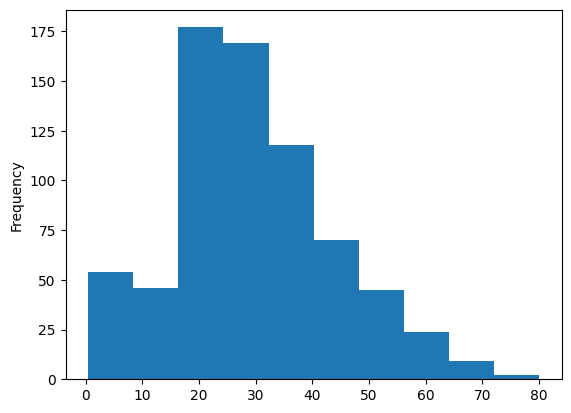

In [165]:
df.Age.plot.hist()